In [5]:
# ใช้จัดการข้อมูลในรูปแบบตาราง
import pandas as pd

# ใช้สำหรับการคำนวณ
import numpy as np

# ใช้สร้างกราฟ
import matplotlib.pyplot as plt

# ใช้แบ่งข้อมูลเป็น Training และ Testing
from sklearn.model_selection import train_test_split

# ใช้ปรับข้อมูลให้อยู่ในมาตรฐานเดียวกัน
from sklearn.preprocessing import StandardScaler

# ใช้สร้างโมเดล K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier

# ใช้วัดความแม่นยำและประเมินผลโมเดล
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:
# อ่านข้อมูลจากไฟล์ zoo2.csv
zoo2 = pd.read_csv("Dataset/zoo2.csv")

# อ่านข้อมูลจากไฟล์ zoo3.csv
zoo3 = pd.read_csv("Dataset/zoo3.csv")

# รวมข้อมูลจากทั้ง 2 ไฟล์เป็น Dataset เดียว
df = pd.concat([zoo2, zoo3], ignore_index=True)

# แสดงขนาดข้อมูลทั้งหมด (จำนวนแถว, จำนวนคอลัมน์)
print("ขนาดข้อมูลทั้งหมด:", df.shape)

# แสดงข้อมูล 5 แถวแรก
df.head()

ขนาดข้อมูลทั้งหมด: (113, 18)


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,turtle,0,0,1,0,0,1,0,0,1,1,0,0,4,1,1,1,3
1,chameleon,0,0,1,0,0,0,0,1,1,1,0,0,4,1,1,0,3
2,iguana,0,0,1,0,0,0,1,1,1,1,0,0,4,1,1,1,3
3,lizard,0,0,1,0,0,0,1,1,1,1,0,0,4,1,0,0,3
4,gecko,0,0,1,0,0,0,0,1,1,1,0,0,4,1,1,0,3


In [7]:
# แสดงรายละเอียดข้อมูล เช่น ชื่อคอลัมน์ ชนิดข้อมูล และจำนวนข้อมูล
df.info()

# ตรวจสอบ Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# แสดงจำนวนข้อมูลในแต่ละประเภทของสัตว์
print("\nจำนวนข้อมูลในแต่ละ Class:")
print(df["class_type"].value_counts().sort_index())

# แสดงสถิติพื้นฐานของข้อมูล
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal_name  113 non-null    object
 1   hair         113 non-null    int64 
 2   feathers     113 non-null    int64 
 3   eggs         113 non-null    int64 
 4   milk         113 non-null    int64 
 5   airborne     113 non-null    int64 
 6   aquatic      113 non-null    int64 
 7   predator     113 non-null    int64 
 8   toothed      113 non-null    int64 
 9   backbone     113 non-null    int64 
 10  breathes     113 non-null    int64 
 11  venomous     113 non-null    int64 
 12  fins         113 non-null    int64 
 13  legs         113 non-null    int64 
 14  tail         113 non-null    int64 
 15  domestic     113 non-null    int64 
 16  catsize      113 non-null    int64 
 17  class_type   113 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 16.0+ KB

Missing Values:
animal

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
count,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000
mean,0.203540,0.176991,0.831858,0.168142,0.256637,0.380531,0.389381,0.469027,0.761062,0.849558,0.132743,0.159292,2.955752,0.619469,0.132743,0.336283,3.637168
std,0.404424,0.383361,0.375658,0.375658,0.438723,0.487680,0.489782,0.501263,0.428334,0.359097,0.340809,0.367578,2.221604,0.487680,0.340809,0.474541,1.950558
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,3.000000
75%,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,5.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,7.000000


In [8]:
# X คือข้อมูล Input หรือคุณลักษณะของสัตว์
# ไม่ใช้ animal_name เพราะเป็นเพียงชื่อสัตว์
# ไม่ใช้ class_type เพราะเป็นคำตอบที่ต้องการทำนาย
X = df.drop(columns=["animal_name", "class_type"])

# y คือ Target หรือประเภทของสัตว์ที่ต้องการทำนาย
y = df["class_type"]

# แสดงขนาดของข้อมูล
print("Features shape:", X.shape)
print("Target shape:", y.shape)

# แสดงตัวอย่างข้อมูล Features
X.head()

Features shape: (113, 16)
Target shape: (113,)


,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
0,0,0,1,0,0,1,0,0,1,1,0,0,4,1,1,1
1,0,0,1,0,0,0,0,1,1,1,0,0,4,1,1,0
2,0,0,1,0,0,0,1,1,1,1,0,0,4,1,1,1
3,0,0,1,0,0,0,1,1,1,1,0,0,4,1,0,0
4,0,0,1,0,0,0,0,1,1,1,0,0,4,1,1,0


In [9]:
# แบ่งข้อมูลเป็น Training 80% และ Testing 20%
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# สร้างตัวปรับมาตรฐานข้อมูล
scaler = StandardScaler()

# ปรับข้อมูล Training Data
X_train_scaled = scaler.fit_transform(X_train)

# ปรับข้อมูล Testing Data
# โดยใช้ค่าที่เรียนรู้จาก Training Data
X_test_scaled = scaler.transform(X_test)

# แสดงขนาดข้อมูลหลังแบ่ง
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nStandardization completed")

Training data: (90, 16)
Testing data: (23, 16)

Standardization completed


In [10]:
# กำหนดค่า k ที่ต้องการทดลอง
k_values = [3, 5, 7]

# สร้าง List สำหรับเก็บผลลัพธ์
results = []

# ทดลองสร้างโมเดล KNN สำหรับแต่ละค่า k
for k in k_values:

    # สร้างโมเดล KNN
    knn = KNeighborsClassifier(n_neighbors=k)

    # ฝึกโมเดลด้วย Training Data
    knn.fit(X_train_scaled, y_train)

    # ทำนาย Testing Data
    y_pred = knn.predict(X_test_scaled)

    # คำนวณ Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # เก็บค่า k และ Accuracy
    results.append([k, accuracy])

    # แสดงผลลัพธ์
    print(f"k = {k}, Accuracy = {accuracy:.4f}")

k = 3, Accuracy = 0.9130
k = 5, Accuracy = 1.0000
k = 7, Accuracy = 0.9565


In [11]:
# สร้างตารางผลลัพธ์
results_df = pd.DataFrame(
    results,
    columns=["k", "Accuracy"]
)

# แสดงตาราง Accuracy ของแต่ละค่า k
print("ผลการทดลอง:")
print(results_df)

# หาผลลัพธ์ที่มี Accuracy สูงที่สุด
best_result = results_df.loc[
    results_df["Accuracy"].idxmax()
]

# เก็บค่า k ที่ดีที่สุด
best_k = int(best_result["k"])

# แสดงผล
print("\nBest k =", best_k)
print("Best Accuracy =", best_result["Accuracy"])

ผลการทดลอง:
   k  Accuracy
0  3  0.913043
1  5  1.000000
2  7  0.956522

Best k = 5
Best Accuracy = 1.0


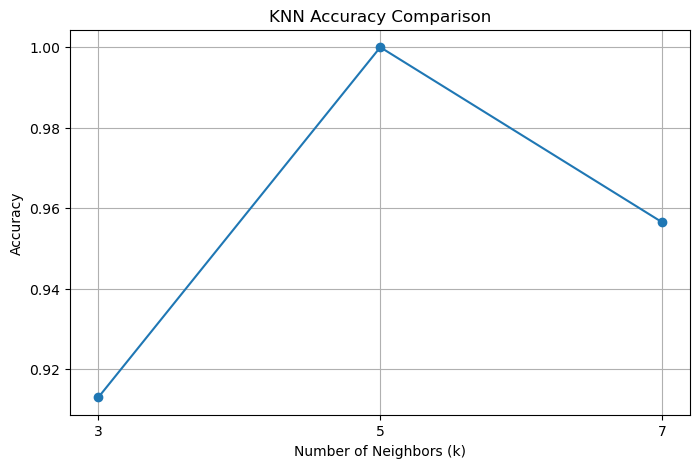

In [12]:
# กำหนดขนาดกราฟ
plt.figure(figsize=(8, 5))

# สร้างกราฟเปรียบเทียบค่า k กับ Accuracy
plt.plot(
    results_df["k"],
    results_df["Accuracy"],
    marker="o"
)

# กำหนดชื่อกราฟและแกน
plt.title("KNN Accuracy Comparison")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")

# กำหนดค่าแกน X
plt.xticks([3, 5, 7])

# แสดงเส้น Grid
plt.grid()

# แสดงกราฟ
plt.show()

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         4
           7       1.00      1.00      1.00         2

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23

Confusion Matrix:
[[4 0 0 0 0 0 0]
 [0 4 0 0 0 0 0]
 [0 0 4 0 0 0 0]
 [0 0 0 3 0 0 0]
 [0 0 0 0 2 0 0]
 [0 0 0 0 0 4 0]
 [0 0 0 0 0 0 2]]


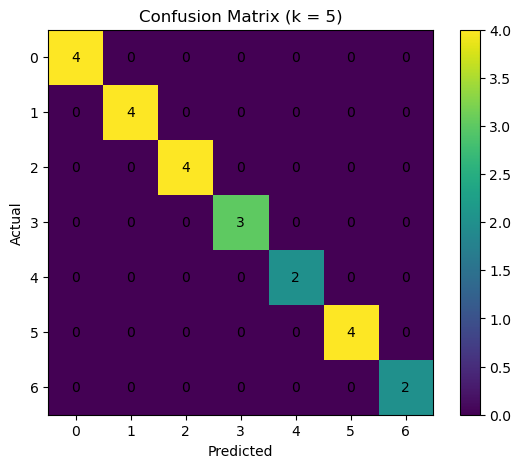

In [13]:
# สร้างโมเดล KNN โดยใช้ค่า k ที่ดีที่สุด
best_knn = KNeighborsClassifier(n_neighbors=best_k)

# ฝึกโมเดล
best_knn.fit(X_train_scaled, y_train)

# ทำนายข้อมูล Testing Data
y_pred_best = best_knn.predict(X_test_scaled)

# แสดง Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_best))

# สร้าง Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

# แสดง Confusion Matrix
print("Confusion Matrix:")
print(cm)

# แสดง Confusion Matrix เป็นกราฟ
plt.figure(figsize=(7, 5))

plt.imshow(cm)

plt.title(f"Confusion Matrix (k = {best_k})")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

# แสดงตัวเลขในแต่ละช่อง
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()